In [22]:
import xarray as xr
import sys, os
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from cloudpathlib import AnyPath

# Local Imports
curdir = os.getcwd()
#print(curdir)
sys.path.insert(0, curdir+"/../../../data_processing")
from ceres_ebaf import *
from ceres_syn import *

sys.path.insert(0, curdir+"/../../../visualization")
from ceres_ebaf_plotting import *

base_path = AnyPath("/Users/mawa7160/dev/data/CERES/")
full_ebaf_filename = "EBAF/CERES_EBAF_Edition4.1_200003-202203.nc"
syn_part_1 = "SYN/CERES_SYN1deg-Day_Terra-Aqua-MODIS_Ed4.1_Subset_20000301-20200325.nc"
syn_part_2 = "SYN/CERES_SYN1deg-Day_Terra-Aqua-MODIS_Ed4.1_Subset_20200326-20240229.nc"

plt.rcParams['figure.figsize'] = [10, 3.5]

# Load the full SYN1deg data
syn_part_1_data = xr.open_dataset(base_path / syn_part_1)
syn_part_2_data = xr.open_dataset(base_path / syn_part_2)   
syn = xr.concat([syn_part_1_data, syn_part_2_data], dim='time')
# Load the full EBAF data
full_ebaf_data = xr.open_dataset(base_path / full_ebaf_filename)

In [24]:
syn_global = apply_spatial_weights(syn["toa_solar_all_daily"], low_lat=-90, high_lat=90)
syn_nh = apply_spatial_weights(syn["toa_solar_all_daily"], low_lat=0, high_lat=90)
syn_sh = apply_spatial_weights(syn["toa_solar_all_daily"], low_lat=-90, high_lat=0)

ebaf_global = apply_spatial_weights(full_ebaf_data["solar_mon"], low_lat=-90, high_lat=90)
ebaf_nh = apply_spatial_weights(full_ebaf_data["solar_mon"], low_lat=0, high_lat=90)
ebaf_sh = apply_spatial_weights(full_ebaf_data["solar_mon"], low_lat=-90, high_lat=0)

In [25]:
# Make Syn Annual averages from Daily Data
years = np.arange(22)+2001
global_syn_daily_means = np.ones(len(years), dtype=float)
nh_syn_daily_means = np.ones_like(global_syn_daily_means)
sh_syn_daily_means = np.ones_like(global_syn_daily_means)

LEAP_YEAR_OFFSET = - (1-0.2425)/2 
NON_LEAP_YEAR_OFFSET = 0.2425/2
for i in range(len(years)):
    if years[i] % 4 == 0:
        offset = LEAP_YEAR_OFFSET
    else:
        offset = NON_LEAP_YEAR_OFFSET
    global_syn_daily_means[i] = make_leap_year_weighted_syn_annual_mean(syn_global, years[i], offset=offset)
    nh_syn_daily_means[i] = make_leap_year_weighted_syn_annual_mean(syn_nh, years[i], offset=offset)
    sh_syn_daily_means[i] = make_leap_year_weighted_syn_annual_mean(syn_sh, years[i], offset=offset)

In [26]:
# Make EBAF Annual averages from Monthly Data
global_ebaf_means = apply_time_averaging(ebaf_global, averaging_method=2)
nh_ebaf_means = apply_time_averaging(ebaf_nh, averaging_method=2)
sh_ebaf_means = apply_time_averaging(ebaf_sh, averaging_method=2)

In [33]:
# Make Syn Monthly averages from Daily Data by resampling
global_syn_monthly = syn_global.resample(time="1M").mean()
nh_syn_monthly = syn_nh.resample(time="1M").mean()
sh_syn_monthly = syn_sh.resample(time="1M").mean()

# Make annual Syn averages from Syn monthly data
global_syn_monthly_means = apply_time_averaging(global_syn_monthly, averaging_method=1)
nh_syn_monthly_means = apply_time_averaging(nh_syn_monthly, averaging_method=1)
sh_syn_monthly_means = apply_time_averaging(sh_syn_monthly, averaging_method=1)

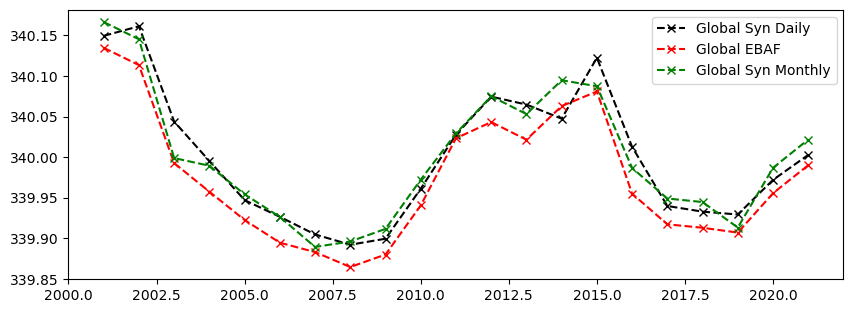

In [34]:
plt.plot(years[:-1], global_syn_daily_means[:-1], "--xk", label="Global Syn Daily")
plt.plot(global_ebaf_means.year[1:], global_ebaf_means[1:], "--xr", label="Global EBAF")
plt.plot(global_syn_monthly_means.year[1:-2], global_syn_monthly_means[1:-2], "--xg", label="Global Syn Monthly")
plt.legend()

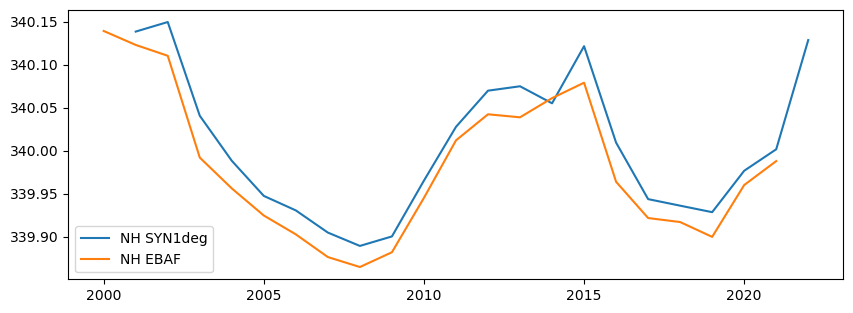

In [7]:
plt.plot(years, nh_syn_daily_means, label="NH SYN1deg")
plt.plot(nh_ebaf_means.year, nh_ebaf_means, label="NH EBAF")
plt.legend()

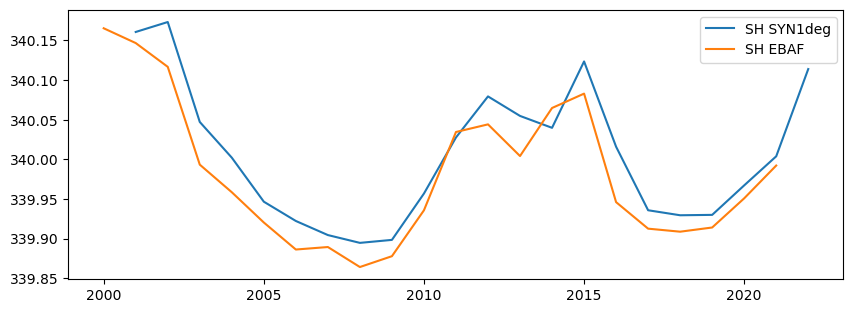

In [8]:
plt.plot(years, sh_syn_daily_means, label="SH SYN1deg")
plt.plot(sh_ebaf_means.year, sh_ebaf_means, label="SH EBAF")
plt.legend()

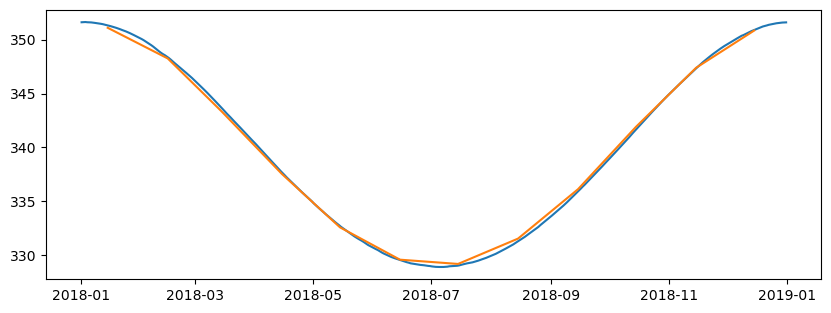

In [9]:
# Check out daily vs monthly averages for 1 year
syn_year = syn_global.sel(time=slice("2018-01-01", "2018-12-31"))
ebaf_year = ebaf_global.sel(time=slice("2018-01-01", "2018-12-31"))
plt.plot(syn_year.time, syn_year)
plt.plot(ebaf_year.time, ebaf_year)

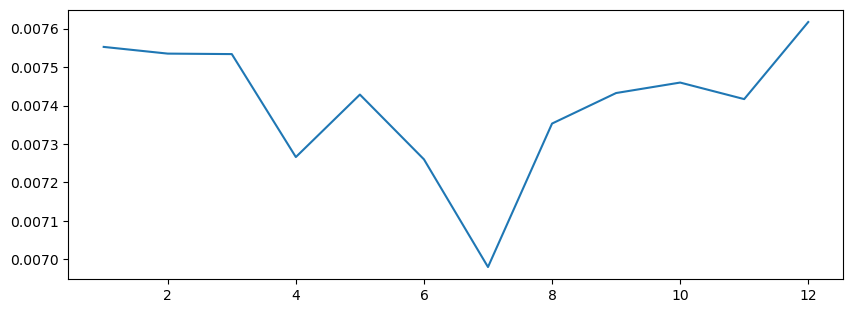

In [10]:
# Check monthly averaging from daily data (2018)
syn_monthly = syn_year.groupby('time.month').mean()
plt.plot(syn_monthly.month, (syn_monthly.data-ebaf_year.data)/syn_monthly.mean().data*100)

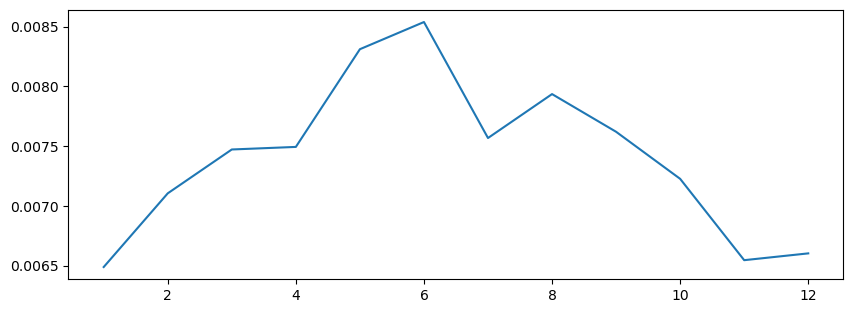

In [11]:
# Check monthly values for nh and sh
syn_nh_year = syn_nh.sel(time=slice("2018-01-01", "2018-12-31"))
syn_nh_monthly = syn_nh_year.groupby('time.month').mean()
ebaf_nh_year = ebaf_nh.sel(time=slice("2018-01-01", "2018-12-31"))
plt.plot(syn_nh_monthly.month, (syn_nh_monthly.values-ebaf_nh_year)/syn_nh_monthly.mean().values*100)

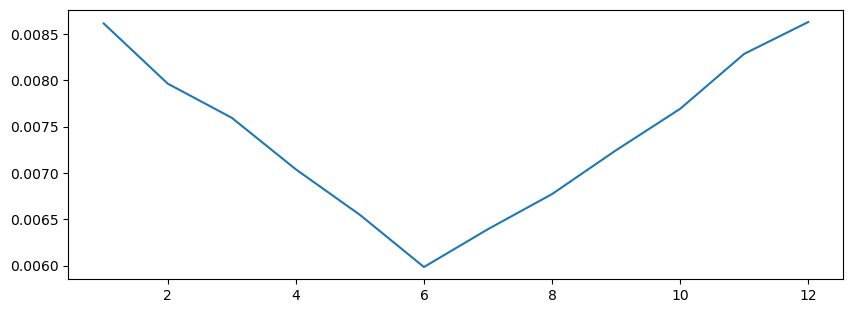

In [12]:
syn_sh_year = syn_sh.sel(time=slice("2018-01-01", "2018-12-31"))
syn_sh_monthly = syn_sh_year.groupby('time.month').mean()
ebaf_sh_year = ebaf_sh.sel(time=slice("2018-01-01", "2018-12-31"))
plt.plot(syn_sh_monthly.month, (syn_sh_monthly.values-ebaf_sh_year)/syn_sh_monthly.mean().values*100)

In [13]:
# Check the annual averages for 2018
syn_glob_day = make_leap_year_weighted_syn_annual_mean(syn_global, 2018, NON_LEAP_YEAR_OFFSET)
ebaf_glob = apply_time_averaging(ebaf_year, averaging_method=2)

syn_glob_month = ebaf_year.copy()
syn_glob_month.values = syn_monthly.values
syn_glob_month_avg = apply_time_averaging(syn_glob_month, averaging_method=2)

In [14]:
print(f"Syn Global Annual Average from Syn Daily Data = {syn_glob_day}")
print(f"EBAF Global Annual Average from EBAF Monthly Averages = {ebaf_glob.values[0]}")
print(f"Syn Global Annual Average from Syn Monthly Averages = {syn_glob_month_avg.values[0]}")

Syn Global Annual Average from Syn Daily Data = 339.9328135987993
EBAF Global Annual Average from EBAF Monthly Averages = 339.90724078367674
Syn Global Annual Average from Syn Monthly Averages = 339.93240719526676
